## Introduction

This project investigates image classification using a [Banana ripeness classification dataset](https://www.kaggle.com/datasets/shahriar26s/banana-ripeness-classification-dataset) from kaggle, composed of images about bananas in different stages of ripeness (unripe, ripe, overripe, rotten).  
The main goal is to evaluate how different representation-learning strategies perform on this task. In particular, the project focuses on convolutional neural networks (CNNs) and a hybrid architecture that combines a CNN with an iterative Deep Belief Network (iDBN). Another important objective is to explore computationally efficient approaches while still maintaining strong classification performance.

A compact CNN is first used as a baseline model. The architecture relies on hierarchical convolutional features and adaptive pooling, allowing it to process images with varying spatial resolutions. In addition to performing end-to-end classification, the internal representations learned by the CNN are analyzed using linear readouts and clustering methods to help provide insight into how information related to banana ripeness is organized within the model’s feature space. Hyperparameters are selected using a dedicated validation set to ensure a fair comparison between models and to reduce the risk of overfitting.

To investigate alternative representation-learning strategies, the CNN is then combined with an iDBN trained on fixed CNN embeddings. In this hybrid setup, the CNN acts as a frozen feature extractor, while the iDBN learns higher-level dependencies in the embedding space through unsupervised, layer-wise training. The resulting representations are again evaluated using linear classifiers, clustering techniques and an overview of the max activating inputs for the hidden layers, allowing a direct comparison with the standalone CNN in terms of structure and generalization. 

Model performance is evaluated using standard classification metrics and confusion matrices, which help highlight class-specific strengths as well as common error patterns, while psychometric curves are also used to study how sensitive the models are to gradual changes in visual ripeness cues, providing a more detailed view of their decision behavior beyond simple accuracy scores. Robustness is further assessed through adversarial perturbations, testing how stable each model’s predictions remain when the input images are intentionally modified to cause misclassification.

Finally, a concluding evaluation is performed on a dedicated test set.

This experimental setup ensures that the reported results reflect genuine generalization performance and enables a systematic comparison between the CNN baseline, the hybrid CNN–iDBN model, and their corresponding linear readouts. Overall, these analyses provide a comprehensive evaluation of representation quality, classification performance, and robustness in the task of estimating banana ripeness from images.


## Preprocessing

The first thing I'm going to do is to import all the libraries needed later, and set a general seed in order to be able to analize and replicate the results.

In [ ]:

from torchvision.datasets import ImageFolder # get images from dataset

import os
from PIL import Image # dataset class
from torch.utils.data import Dataset # dataset class
import torchvision.transforms as transforms # images transforms
from torch.utils.data import Subset, DataLoader, ConcatDataset #  data loader and concatenate the folds ###### subset?

import matplotlib.pyplot as plt # show image

import torch
import numpy as np
import random # set_seed

import torch.nn as nn # CNN
from tqdm import tqdm # evaluation
import torch.optim as optim # optimizer CNN

import scipy.cluster as cluster # clusters
from scipy.spatial.distance import pdist

from sklearn.metrics import confusion_matrix

import pickle # to save data even after closing the notebook



In [3]:
seed = 99
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


Before downloading all of the data, since I'm planning on normalizing the images 

Before getting the data I'm first going to define some preprocessing for the images.
For example normalize the RGB color values, so that we can have a much clearer difference between the yellow of the bananas and the background or the brown spots on it to define its ripeness.
To do so I'll use the ImageNet's values for the RGB mean and standard deviation.

Also for computational and memory size reasons I'm going to resize the whole image to 36x36 pixels, while whole cropping the image a bit more than the original image since many of them are rotated squares with edges, so like this I won't have missing pixels in the corners of the images. Reducing to only 32x32 pixels might get worse results, but considering the kind of images I'm working with, it might be the better choice, since we are not looking for particularly small details in the images, but mainly a difference in color, meaning that reducing the number of pixels shouldn't impact much on the performances.

To make the dataset better represent all kinds of potential images, I chose to add a random horizzontal and vertical flip to the train images, since banans could appear in every position and angle immaginable unlike other kinds of objects.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

batch_size = 64

Device: cpu


In [5]:
norm_mean = torch.tensor([0.485, 0.456, 0.406])
norm_std = torch.tensor([0.229, 0.224, 0.225])

# transforms I'll be using in the project
train_transform = transforms.Compose([
    transforms.Resize(36),
    transforms.RandomCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=norm_mean,
        std=norm_std
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize(36),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=norm_mean,
        std=norm_std
    )

])




train_dataset = ImageFolder("banana_dataset/train", transform=train_transform)
val_dataset = ImageFolder("banana_dataset/valid", transform=val_test_transform)
test_dataset = ImageFolder("banana_dataset/test", transform=val_test_transform)

Since the dataset were already divided into train validation and test, let's just check how well the classes are distributed among them and in total.

In [ ]:
n_classes = len(train_dataset.classes)
print("Number of classes: ", n_classes)
print(train_dataset.classes)

train_classes_division = np.bincount(train_dataset.targets)
val_classes_division = np.bincount(val_dataset.targets)
test_classes_division = np.bincount(test_dataset.targets)

print("\nTotal examples per class:")
for i in range(3):
    print(f"{train_dataset.classes[i]}: {sum([train_classes_division[i], val_classes_division[i], val_classes_division[i]])}")



print("\nDistribution of the classes in each set:")
print("Train: ", train_classes_division, "Total: ", len(train_dataset))
print("Val: ", val_classes_division, "Total: ", len(val_dataset))
print("Test: ", test_classes_division, "Total: ", len(test_dataset))

print("\nPercentage distribution of the classes in each set:")
print(train_classes_division / sum(train_classes_division))
print(val_classes_division / sum(val_classes_division))
print(test_classes_division / sum(test_classes_division))



Number of classes:  4
['overripe', 'ripe', 'rotten', 'unripe']

Total examples per class:
overripe: 2807
ripe: 4200
rotten: 4796

Distribution of the classes in each set:
Train:  [2349 3522 4020 1902] Total:  11793
Val:  [229 339 388 167] Total:  1123
Test:  [113 154 185 110] Total:  562

Percentage distribution of the classes in each set:
[0.19918596 0.29865174 0.34088018 0.16128212]
[0.20391808 0.30186999 0.34550312 0.14870882]
[0.20106762 0.27402135 0.32918149 0.19572954]


The classes are well distributed among each of the sets, with some inbalance in thei amount, but not too problematic.

In [7]:

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.0822659].


torch.Size([3, 32, 32])
Image number: 0


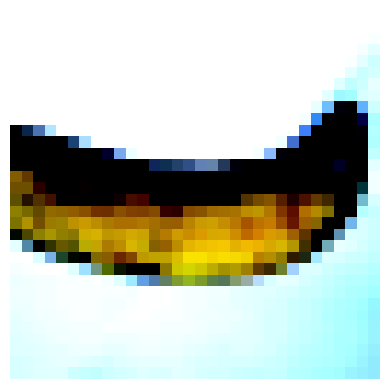

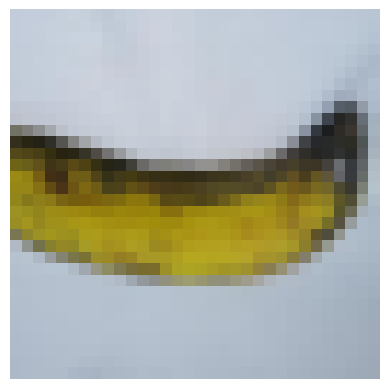

In [8]:
img, label = train_loader.dataset[11]
print(img.shape)   # 3 RGB channels, 32x32 pixels

# Plot an image (with or without normalization)
def plot_image(image, denorm = False):
    if denorm == True:
        image = image * norm_std[:, None, None] + norm_mean[:, None, None]

    # since image is a tensor, it converts it from [color = 3, height, width]  to [height, width, color = 3]
    image_np = image.permute(1, 2, 0).numpy() # channels as last dimension

    plt.imshow(image_np)
    plt.axis('off')
    plt.show()

print("Image number:", label)
plot_image(img) # original
plot_image(img, denorm = True) # normalized

Thanks to the normalization, the difference of colors is much more marked, which will be very helpful for the classification.


## CNN

Here I implement a compact convolutional neural network (CNN).  
The architecture follows a hierarchical feature extraction paradigm, where successive convolutional blocks capture increasingly abstract visual patterns, from low-level edges and textures to high-level features. Spatial resolution is progressively reduced through max pooling, which increases the effective receptive field while keeping the computational cost manageable. To improve training stability, I also added group normalization to normalize feature statistics within the channel groups. I tried also with batch normalization, meaning normalizing across the batch, but i found it not effective enough.  

After, non-linear ReLU activations are applied after each normalization step, enabling the model to learn complex, non-linear decision boundaries. To make the architecture independent of the input image resolution, the final convolutional block uses adaptive average pooling to aggregate spatial information into a fixed-size global representation. This pooled feature vector serves as a compact embedding that summarizes the image content. Finally, a linear classifier maps this embedding to class logits, with dropout applied to reduce overfitting and improve generalization.

In [9]:
# CNN
class ConvolutionalNN(nn.Module):
    """CNN with adaptive pooling so it accepts arbitrary input resolution."""

    def __init__(self, num_classes=n_classes, base_channels=32, dropout=0.1):
        super().__init__()

        # First convolutional block: low-level feature extraction
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1),
            # nn.BatchNorm2d(base_channels),
            nn.GroupNorm(8, base_channels), # good for noise and overall stability of predictions

            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),         # H/2, W/2
        )
        
        # Second block: mid-level features
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1),
            # nn.BatchNorm2d(base_channels*2),
            nn.GroupNorm(8, base_channels*2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),         # H/4, W/4
        )

        # Third block: high-level features + global pooling
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=3, padding=1),
            # nn.BatchNorm2d(base_channels*4),
            nn.GroupNorm(8, base_channels*4),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)), # Makes the model independent of input size
        )

        self.embedding_dim = base_channels * 4

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.embedding_dim, num_classes)
        )

    def forward(self, x):
        f1 = self.conv1(x)         # early features
        f2 = self.conv2(f1)        # mid features
        f3 = self.conv3(f2)        # deep features → pooled to (1,1)

        # Flatten everything to (batch, embedding_dim)
        emb = torch.flatten(f3, 1)
        logits = self.classifier(emb) # Class scores
        return logits, {"f1": f1, "f2": f2, "f3": emb}

## Training and Evaluation

Model training is performed using a standard supervised learning loop. During each training epoch, the model is set to training mode and iterates over mini-batches of images and labels.  
For each batch, gradients are reset, and a forward pass produces classification logits, then the loss is computed using Cross Entropy, followed by backpropagation to compute gradients, and the optimizer updates the model parameters. 
Training loss is accumulated as a weighted average over the samples, and accuracy is computed by comparing the predicted class indices with the true labels.

Evaluation is carried out at the end of each epoch and the same loss and accuracy metrics are computed over the validation set without updating the model's parameters. 
In addition to performance metrics, the evaluation loop stores predicted labels, true labels, and intermediate feature representations extracted from a specified layer (the final CNN embedding in this case) for all samples. 
Training proceeds for a fixed number of epochs, and losses and accuracies for both training and evaluation splits are recorded and reported after each epoch.

In [144]:
# Training of a single epoch
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()                           # Enable training mode
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Train', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, _ = model(images)           # forward pass
        loss = criterion(logits, labels)
        loss.backward()                     # Backpropagation

        optimizer.step()                    # Update model parameters

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


# evaluation of a single epoch
@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device, is_CNN = True): # is_CNN added for distinction between CNN and CNN + iDBN
    model.eval()                                 # Put model in evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []                               # Store predictions from all batches
    all_labels = []                              # Store ground-truth labels
    features_list = []                           # Store extracted features for all samples

    if is_CNN:
        feature_key = "f3" # CNN
    else:
        feature_key = "idbn_z" # iDBN
    
    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        logits, features = model(images)            # Forward pass: classification logits + feature dict

        # Compute batch loss
        running_loss += criterion(logits, labels).item() * images.size(0)

        preds = logits.argmax(dim=1)             # Get predicted class index per sample
        correct += (preds == labels).sum().item()# Update accuracy
        total += images.size(0)                  # Count how many samples have been processed

        all_preds.append(preds.cpu().numpy())    # Save predictions 
        all_labels.append(labels.cpu().numpy())  # Save labels

        features_list.append(features[feature_key].cpu().numpy())


    # Concatenate stored arrays into full evaluation results
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    features = np.concatenate(features_list, axis=0) 

    # Compute final average loss
    avg_loss = running_loss / total

    return avg_loss, correct / total, all_preds, all_labels, features


# training for multiple epochs
def train(model, train_loader, test_loader, criterion, optimizer, epochs = 10, is_CNN = True, device = device, verbose = True):
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device=device)
        # print("Finished training")

        test_loss, test_acc, y_pred, y_true, features = evaluate_epoch(model, test_loader, criterion, device=device, is_CNN = is_CNN)
        # print("Finished evaluation")

        if verbose:
            print(f"Epoch {epoch+1:02d} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
                f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}")
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
    
    return {"model": model, # trained model
            "tr_losses": train_losses, 
            "ts_losses": test_losses, 
            "tr_accs": train_accs, 
            "ts_accs": test_accs,
            "y_pred": y_pred, # predicted y
            "y_true": y_true, # true y
            "features": features}




For the loss I will use the cross entropy function, by also adding a bit of label smoothing to adjust for noise.

For now for the optimizer I will use the default values, later I will be doing hyperparameter tuning to get the best values for the learning rate and the weight decay.

In [ ]:
basic_CNN_model = ConvolutionalNN().to(device)

basic_CNN_criterion = nn.CrossEntropyLoss(label_smoothing=0.05).to(device) # label smoothing, useful for noise 

basic_CNN_optimizer = optim.Adam(basic_CNN_model.parameters())


In [26]:
basic_CNN = train(basic_CNN_model, train_loader, val_loader, criterion=basic_CNN_criterion, optimizer=basic_CNN_optimizer, epochs=30)


Epoch 01 | Train Loss: 0.7101 | Train Acc: 0.750 | Test Loss: 0.5016 | Test Acc: 0.872


Epoch 02 | Train Loss: 0.4959 | Train Acc: 0.867 | Test Loss: 0.4979 | Test Acc: 0.890


Epoch 03 | Train Loss: 0.4647 | Train Acc: 0.883 | Test Loss: 0.4750 | Test Acc: 0.885


Epoch 04 | Train Loss: 0.4242 | Train Acc: 0.906 | Test Loss: 0.3798 | Test Acc: 0.930


Epoch 05 | Train Loss: 0.4013 | Train Acc: 0.917 | Test Loss: 0.3607 | Test Acc: 0.945


...

Epoch 26 | Train Loss: 0.2998 | Train Acc: 0.962 | Test Loss: 0.2924 | Test Acc: 0.969


Epoch 27 | Train Loss: 0.2979 | Train Acc: 0.961 | Test Loss: 0.2895 | Test Acc: 0.966


Epoch 28 | Train Loss: 0.2932 | Train Acc: 0.964 | Test Loss: 0.2842 | Test Acc: 0.971


Epoch 29 | Train Loss: 0.2901 | Train Acc: 0.965 | Test Loss: 0.2804 | Test Acc: 0.972


Epoch 30 | Train Loss: 0.2912 | Train Acc: 0.965 | Test Loss: 0.2887 | Test Acc: 0.963


In [ ]:
# Save the model to file
# save data
# with open("basic_CNN_banana.pkl", "wb") as f:
#     pickle.dump(basic_CNN, f)

# get saved data
# with open("basic_CNN_banana.pkl", "rb") as f:
#     basic_CNN = pickle.load(f)

The model already performs quite well, achieving a high classification accuracy in the validation set of around 97%, demonstrating that banana ripeness can be effectively recognized even from low-resolution images.

It's also worth looking at the fact that the validation loss is lower than the train loss, which isn't much of a surprise because of all the things added to the train only dataset like horizontal and vertical flips, or tha addition of dropout.

Even if the model is already good, it can still be better, so let's try to make some hyperparameter tuning.

## Hyperparameters tuning

Here I'm just doing a grid search over different values of the learning rate and weight decay, and refining the search with each steps by looking at the models that perform best, while also trying different seeds to avoid particular scenarios. 

In [ ]:
# grid search, run the trainig for every combination of learning rate and weight decay
def hyperparameters_tuning(is_CNN, learning_rates, weight_decays, seed, epochs = 15, verbose = True):
    best_accuracy = 0
    all_trained_models = []
    best_lr = -1
    best_wd = -1

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05).to(device) # same for both CNN and MLP

    for lr in learning_rates:
        for wd in weight_decays:
            print(f"Starting model with: learning rate = {lr}, weight decay = {wd}")
            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)

            model = ConvolutionalNN().to(device)

            
            
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

            trained_model = train(model, train_loader, val_loader, criterion=criterion, optimizer=optimizer, epochs=epochs, verbose = verbose)

            if best_accuracy < max(trained_model["ts_accs"]):
                best_lr = lr
                best_wd = wd
                best_accuracy = max(trained_model["ts_accs"])

            all_trained_models.append(trained_model)

            print(f"Model with: learning rate = {lr}, weight decay = {wd}, finished")
            print("-------------------------")
    
    return all_trained_models, best_lr, best_wd



Since I'm doing tuning only on 15 runs and with a dataset that is not too computationally expensive, I'm going to check the models' results one by one, instead of trusting blindly the one with higher accuracy or other automatic methods, so I can trsut more the model that I end up choosing.  

### CNN tuning

In [ ]:
CNN_learning_rates_1 = [0.0001, 0.001, 0.01]
CNN_weight_decays_1 = [0, 0.00001, 0.001]

CNN_tuning_results_1 = hyperparameters_tuning(learning_rates = CNN_learning_rates_1, weight_decays = CNN_weight_decays_1, seed = 100)


Starting model with: learning rate = 0.0001, weight decay = 0


Epoch 01 | Train Loss: 0.9301 | Train Acc: 0.671 | Test Loss: 0.6347 | Test Acc: 0.821


Epoch 02 | Train Loss: 0.5889 | Train Acc: 0.828 | Test Loss: 0.5316 | Test Acc: 0.857


Epoch 03 | Train Loss: 0.5206 | Train Acc: 0.861 | Test Loss: 0.4865 | Test Acc: 0.871


Epoch 04 | Train Loss: 0.4876 | Train Acc: 0.878 | Test Loss: 0.4613 | Test Acc: 0.893


...

Epoch 11 | Train Loss: 0.4315 | Train Acc: 0.903 | Test Loss: 0.3925 | Test Acc: 0.925


Epoch 12 | Train Loss: 0.4369 | Train Acc: 0.901 | Test Loss: 0.4256 | Test Acc: 0.918


Epoch 13 | Train Loss: 0.4263 | Train Acc: 0.905 | Test Loss: 0.4447 | Test Acc: 0.888


Epoch 14 | Train Loss: 0.4226 | Train Acc: 0.909 | Test Loss: 0.4381 | Test Acc: 0.901


Epoch 15 | Train Loss: 0.4201 | Train Acc: 0.911 | Test Loss: 0.4045 | Test Acc: 0.931
Model with: learning rate = 0.01, weight decay = 0.001, finished
-------------------------


The best model seems the one with learning rate = 0.01 and weight decay = 1e-05.  
Since it has the best accuracy towards the final epochs, even though it has some spikes in the values of the loss and accuracy, they are not too big so we still prefer this model in respect to one with lower accuracy but smoother loss like the ones with higher learning rate.

Having 0.01 learning rate also implies a faster convergence, which is good for limiting the use of computational resources.

To find the optimal values, and also to avoid using only 1 example to chose the parameter, I'll now be doing a second tuning, using learning = 0.01 but also adding more weight decay parameters

In [ ]:
# save data
# with open("CNN_tuning_results_1.pkl", "wb") as f:
#     pickle.dump(CNN_tuning_results_1, f)

# get saved data
# with open("CNN_tuning_results_1.pkl", "rb") as f:
#     CNN_tuning_results_1 = pickle.load(f)

In [ ]:
CNN_learning_rates_2 = [0.01]
CNN_weight_decays_2 = [0, 0.000001, 0.00001, 0.0001]

CNN_tuning_results_2 = hyperparameters_tuning(learning_rates = CNN_learning_rates_2, weight_decays = CNN_weight_decays_2, seed = 101)

Starting model with: learning rate = 0.01, weight decay = 0


Epoch 01 | Train Loss: 1.1373 | Train Acc: 0.488 | Test Loss: 0.5970 | Test Acc: 0.817


Epoch 02 | Train Loss: 0.5642 | Train Acc: 0.827 | Test Loss: 0.4688 | Test Acc: 0.878


Epoch 03 | Train Loss: 0.4941 | Train Acc: 0.864 | Test Loss: 0.4254 | Test Acc: 0.911


Epoch 04 | Train Loss: 0.4299 | Train Acc: 0.901 | Test Loss: 0.3778 | Test Acc: 0.933


...

Epoch 11 | Train Loss: 0.3592 | Train Acc: 0.937 | Test Loss: 0.3633 | Test Acc: 0.934


Epoch 12 | Train Loss: 0.3638 | Train Acc: 0.936 | Test Loss: 0.3245 | Test Acc: 0.955


Epoch 13 | Train Loss: 0.3676 | Train Acc: 0.932 | Test Loss: 0.3185 | Test Acc: 0.963


Epoch 14 | Train Loss: 0.3497 | Train Acc: 0.941 | Test Loss: 0.3233 | Test Acc: 0.953


Epoch 15 | Train Loss: 0.3504 | Train Acc: 0.940 | Test Loss: 0.3228 | Test Acc: 0.954
Model with: learning rate = 0.01, weight decay = 0.0001, finished
-------------------------


Seems like for this run the best weight decay values is either 0 or 1e-6, between the 2 I would prefer the one with 0.000001 since it has a smoother convergence while still having similar loss and accuracy.
In the first tuning, a weight decay of 1e-5 did better than now, compared to a weight decay of 0.
So i prefer to do another run to get a better understanding of which is the best one.  

In [ ]:
# save data
# with open("CNN_tuning_results_2.pkl", "wb") as f:
#     pickle.dump(CNN_tuning_results_2, f)

In [ ]:
CNN_learning_rates_3 = [0.01]
CNN_weight_decays_3 = [0, 0.000001, 0.00001]

CNN_tuning_results_3 = hyperparameters_tuning(learning_rates = CNN_learning_rates_3, weight_decays = CNN_weight_decays_3, seed = 102)

Starting model with: learning rate = 0.01, weight decay = 0


Epoch 01 | Train Loss: 0.9078 | Train Acc: 0.638 | Test Loss: 0.5235 | Test Acc: 0.843


Epoch 02 | Train Loss: 0.5409 | Train Acc: 0.836 | Test Loss: 0.4835 | Test Acc: 0.871


Epoch 03 | Train Loss: 0.4776 | Train Acc: 0.877 | Test Loss: 0.4456 | Test Acc: 0.887


Epoch 04 | Train Loss: 0.4396 | Train Acc: 0.895 | Test Loss: 0.4616 | Test Acc: 0.883


...

Epoch 11 | Train Loss: 0.3599 | Train Acc: 0.933 | Test Loss: 0.3756 | Test Acc: 0.942


Epoch 12 | Train Loss: 0.3451 | Train Acc: 0.942 | Test Loss: 0.3174 | Test Acc: 0.962


Epoch 13 | Train Loss: 0.3408 | Train Acc: 0.944 | Test Loss: 0.3427 | Test Acc: 0.946


Epoch 14 | Train Loss: 0.3307 | Train Acc: 0.948 | Test Loss: 0.3597 | Test Acc: 0.945


Epoch 15 | Train Loss: 0.3333 | Train Acc: 0.948 | Test Loss: 0.3029 | Test Acc: 0.958
Model with: learning rate = 0.01, weight decay = 1e-05, finished
-------------------------


After considering all runs, I believe the best model is the one with learning rate = 0.01 and weight decay = 0, since it consistently got the better result, with similar variance in the loss and accuracy values.
For sure the best isn't the model with weight decay = 0.00001 since it did notably worse than both of the other 2, 2 times out of 3.

Final best CNN model: learning rate = 0.01, weight decay = 0 


In [ ]:
# save data
# with open("CNN_tuning_results_3.pkl", "wb") as f:
#     pickle.dump(CNN_tuning_results_3, f)

## Train tuned CNN

In [ ]:
# Final best CNN model: learning rate = 0.01, weight decay = 0 
# Final best MLP model: learning rate = 0.005, weight decay = 0.00001 

CNN_model = ConvolutionalNN().to(device)

CNN_criterion = nn.CrossEntropyLoss(label_smoothing=0.05).to(device) # label smoothing, useful for noise 

CNN_optimizer = optim.Adam(CNN_model.parameters(), lr=0.01, weight_decay=0)


In [21]:
CNN = train(CNN_model, train_loader, val_loader, criterion=CNN_criterion, optimizer=CNN_optimizer, epochs=30)

Epoch 01 | Train Loss: 0.7492 | Train Acc: 0.718 | Test Loss: 0.6835 | Test Acc: 0.767


Epoch 02 | Train Loss: 0.5018 | Train Acc: 0.863 | Test Loss: 0.4410 | Test Acc: 0.900


Epoch 03 | Train Loss: 0.4506 | Train Acc: 0.888 | Test Loss: 0.3947 | Test Acc: 0.928


Epoch 04 | Train Loss: 0.4349 | Train Acc: 0.897 | Test Loss: 0.4160 | Test Acc: 0.898


Epoch 05 | Train Loss: 0.3986 | Train Acc: 0.915 | Test Loss: 0.3743 | Test Acc: 0.927


...

Epoch 26 | Train Loss: 0.2712 | Train Acc: 0.974 | Test Loss: 0.2761 | Test Acc: 0.975


Epoch 27 | Train Loss: 0.2765 | Train Acc: 0.971 | Test Loss: 0.2715 | Test Acc: 0.977


Epoch 28 | Train Loss: 0.2709 | Train Acc: 0.974 | Test Loss: 0.2824 | Test Acc: 0.972


Epoch 29 | Train Loss: 0.2650 | Train Acc: 0.977 | Test Loss: 0.2860 | Test Acc: 0.964


Epoch 30 | Train Loss: 0.2732 | Train Acc: 0.972 | Test Loss: 0.2715 | Test Acc: 0.978


We can see a clear improvement from before and after tuning the parameters  

Basic CNN: Epoch 30 | Train Loss: 0.2912 | Train Acc: 0.965 | Test Loss: 0.2887 | Test Acc: 0.963  
tuned CNN: Epoch 30 | Train Loss: 0.2732 | Train Acc: 0.972 | Test Loss: 0.2715 | Test Acc: 0.978


In [ ]:
# To save the models for testing:
# # save data
# with open("CNN_banana.pkl", "wb") as f:
#     pickle.dump(CNN, f)


# get saved data
# with open("CNN_banana.pkl", "rb") as f:
#     CNN = pickle.load(f)


In [139]:
# plot a model's accuracy/loss
def plot_loss_accuracy(model, model_name, accuracy=True, ax=None):
    epochs = range(1, len(model["tr_accs"]) + 1)

    if ax is None:
        fig, ax = plt.subplots()

    if accuracy:
        ax.plot(epochs, model["tr_accs"], label="Train Accuracy")
        ax.plot(epochs, model["ts_accs"], label="Test Accuracy")
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{model_name} - Train and Test Accuracy")
    else:
        ax.plot(epochs, model["tr_losses"], label="Train Loss")
        ax.plot(epochs, model["ts_losses"], label="Test Loss")
        ax.set_ylabel("Loss")
        ax.set_title(f"{model_name} - Train and Test Loss")

    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

    if ax is None:
        plt.show()

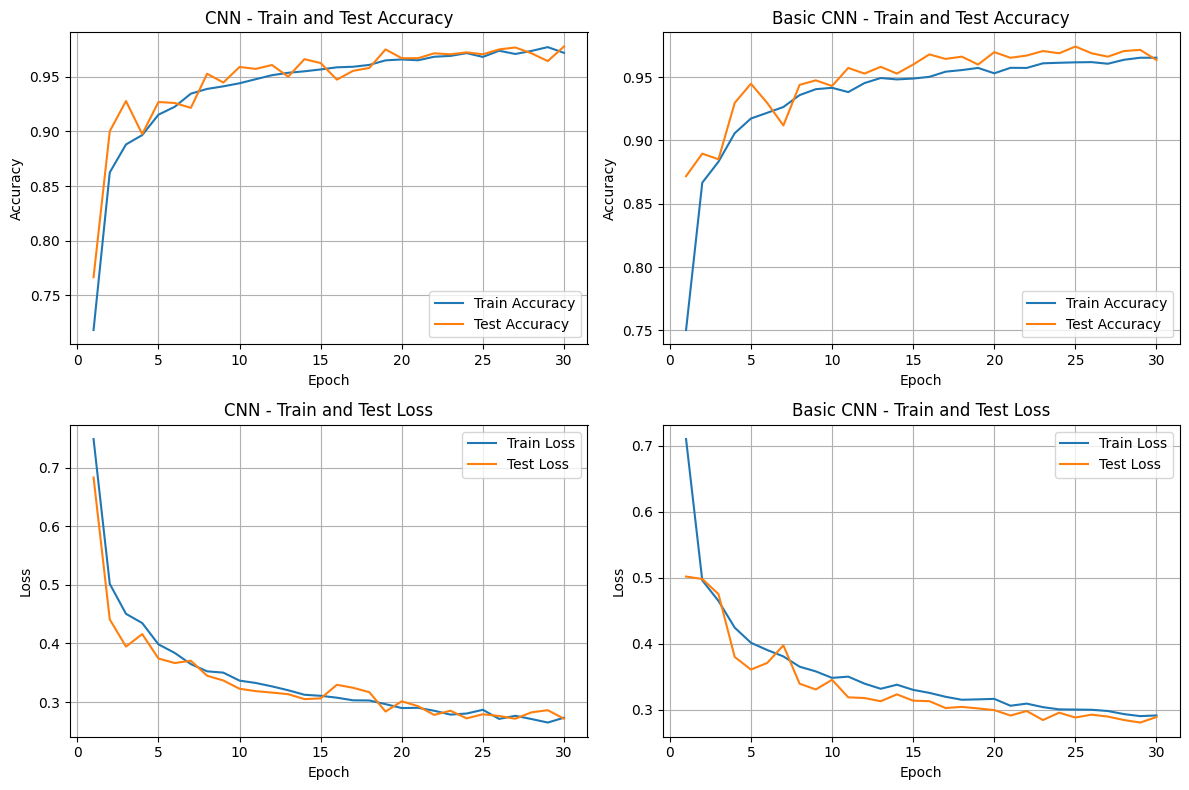

In [138]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_loss_accuracy(CNN, model_name = "CNN", accuracy=True,  ax=axes[0, 0])
plot_loss_accuracy(basic_CNN, model_name = "Basic CNN", accuracy=True,  ax=axes[0, 1])
plot_loss_accuracy(CNN, model_name = "CNN", accuracy=False, ax=axes[1, 0])
plot_loss_accuracy(basic_CNN, model_name = "Basic CNN", accuracy=False, ax=axes[1, 1])

plt.tight_layout()
plt.show()

All 4 plot look very good and very similar, with the main differences that the validation for the tuned CNN is a bit less variable and manages to reach slight better results, but still both reach great results, and the tuning definately improved the classification, even if there isn't much room for improvement.

## iDBN

After training the CNN independently, it is switched to evaluation mode and its parameters are frozen by disabling gradient computation. This ensures that the CNN acts strictly as a fixed feature extractor in the subsequent stages and that its learned representations are not altered when integrating the iDBN or training the final classifier.

In [145]:
cnn = CNN["model"]
cnn.eval() # Freeze the CNN

for p in cnn.parameters():
    p.requires_grad = False

In [146]:
# extract feature embeddings
def extract_cnn_embeddings(cnn, images):
    with torch.no_grad():
        _, feats = cnn(images)
    return feats["f3"]  # shape: (B, 128)

The RBM class implements a standard Restricted Boltzmann Machine with Bernoulli visible and hidden units. It defines learnable weights and biases, along with sampling functions for hidden and visible layers based on sigmoid activations. Contrastive Divergence with one Gibbs step (CD-1) is used to compute positive and negative phase samples, which are later employed for parameter updates.

In [147]:
class RBM(nn.Module):
    def __init__(self, n_vis, n_hid):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_vis, n_hid) * 0.01)
        self.b = nn.Parameter(torch.zeros(n_vis))
        self.c = nn.Parameter(torch.zeros(n_hid))

    def sample_h(self, v):
        p_h = torch.sigmoid(v @ self.W + self.c)
        h = torch.bernoulli(p_h)
        return p_h, h

    def sample_v(self, h):
        p_v = torch.sigmoid(h @ self.W.t() + self.b)
        v = torch.bernoulli(p_v)
        return p_v, v

    def cd1(self, v):
        # Positive phase
        p_h_pos, h_pos = self.sample_h(v)

        # Negative phase
        p_v_neg, v_neg = self.sample_v(h_pos)
        p_h_neg, h_neg = self.sample_h(v_neg)

        return v, h_pos, v_neg, h_neg

To better model real-valued CNN embeddings, a Gaussian RBM variant is introduced. In this case, the visible units follow a Gaussian distribution, while the hidden units remain Bernoulli. The visible reconstruction step samples from a Gaussian distribution with learned mean and fixed variance, making this RBM suitable for continuous-valued feature vectors rather than binary inputs.

In [ ]:

class GaussianRBM(nn.Module):
    def __init__(self, n_vis, n_hid):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_vis, n_hid) * 0.05)
        self.b = nn.Parameter(torch.zeros(n_vis))
        self.c = nn.Parameter(torch.zeros(n_hid))

    def sample_h(self, v):
        p_h = torch.sigmoid(v @ self.W + self.c)
        return p_h, torch.bernoulli(p_h)

    def sample_v(self, h):
        # Gaussian visible units
        mean_v = h @ self.W.t() + self.b
        v = mean_v + torch.randn_like(mean_v) * 0.5
        return mean_v, v

    def cd1(self, v):
        p_h_pos, h_pos = self.sample_h(v)
        v_mean, v_neg = self.sample_v(h_pos)
        p_h_neg, h_neg = self.sample_h(v_neg)
        return v, h_pos, v_neg, h_neg



The iDBN class stacks multiple Gaussian RBMs into a deep architecture. The forward method defines a deterministic inference pass through the network by applying successive linear transformations using the RBM weights and biases. This produces progressively higher-level representations of the input features.  

The iDBN is trained using an iterative, layer-wise procedure based on Contrastive Divergence. For each epoch, the original input features are preserved, and each RBM is trained independently using CD-1 updates. After training a layer, hidden activations are sampled and propagated upward to serve as input for the next RBM. At the end of each epoch, the input is reset, following the iterative training scheme, and progress is periodically reported.

In [149]:
class iDBN(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        self.rbms = nn.ModuleList([
            GaussianRBM(layer_sizes[i], layer_sizes[i+1])
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x):
        # deterministic forward pass (mean activations)
        for rbm in self.rbms:
            x = x @ rbm.W + rbm.c 

        return x

    def iterative_train(self, X, lr=1e-3, epochs=50):
        for epoch in range(epochs):
            Xtmp = X.clone()

            for rbm in self.rbms:
                v = X

                v_pos, h_pos, v_neg, h_neg = rbm.cd1(v)

                rbm.W.data += lr * (
                    v_pos.t() @ h_pos - v_neg.t() @ h_neg
                ) / v.size(0)

                rbm.b.data += lr * (v_pos - v_neg).mean(0)
                rbm.c.data += lr * (h_pos - h_neg).mean(0)

                # propagate hidden activations upward
                X, _ = rbm.sample_h(v)

            # reset input
            X = Xtmp

            if epoch % 10 == 0:
                print(f"iDBN epoch {epoch}")
        print("Iterative training finished")


In [150]:
# Extract CNN embeddings
all_embeddings = []

for images, _ in train_loader:
    images = images.to(device)
    emb = extract_cnn_embeddings(cnn, images)
    all_embeddings.append(emb)

X = torch.cat(all_embeddings, dim=0)


In [151]:
mu = X.mean(dim=0)
std = X.std(dim=0) + 1e-6

X_norm = (X - mu) / std


In [ ]:
X.shape # Visible layer of the iDBN

torch.Size([11793, 128])

During inference, the input image is processed by the CNN to obtain embeddings, which are normalized and passed through the iDBN using a deterministic forward pass. Gradient computation is explicitly disabled throughout this process. The resulting iDBN features are fed into the trainable linear classifier, and intermediate representations from both the CNN and iDBN are returned for analysis.

In [ ]:
class CovolutionalNN_iDBN(nn.Module):
    def __init__(self, cnn, idbn, num_classes):
        super().__init__()
        self.cnn = cnn
        self.idbn = idbn
        self.register_buffer("mu", mu)
        self.register_buffer("std", std)
        
        for p in self.cnn.parameters():
            p.requires_grad = False
        for p in self.idbn.parameters():
            p.requires_grad = False

        self.cnn.eval()
        self.idbn.eval()

        self.classifier = nn.Linear(
            idbn.rbms[-1].c.numel(),
            num_classes
        )

    def forward(self, x):
        with torch.no_grad():
            _, cnn_feats = self.cnn(x)
            z_cnn = cnn_feats["f3"]
            z_cnn = (z_cnn - mu) / std
            z_idbn = self.idbn(z_cnn)

        logits = self.classifier(z_idbn)

        return logits, {
            "cnn_f3": z_cnn,
            "idbn_z": z_idbn
        }


In [152]:
# Train the iDBN
idbn = iDBN(layer_sizes=[128, 256, 128, 64]).to(device)
idbn.iterative_train(X_norm, lr=1e-3, epochs=100)


iDBN epoch 0
iDBN epoch 10
iDBN epoch 20
iDBN epoch 30
iDBN epoch 40
iDBN epoch 50
iDBN epoch 60
iDBN epoch 70
iDBN epoch 80
iDBN epoch 90
Iterative training finished


Once trained the iDBN, it is integrated into the hybrid CNN–iDBN model. 

In [ ]:
CNN_iDBN_model = CovolutionalNN_iDBN(cnn, idbn, num_classes=n_classes).to(device)

CNN_iDBN_optimizer = optim.Adam(CNN_iDBN_model.classifier.parameters(), lr=5e-3)
CNN_iDBN_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

CNN_iDBN = train(CNN_iDBN_model, train_loader, val_loader, criterion=CNN_iDBN_criterion, optimizer=CNN_iDBN_optimizer, epochs=30, is_CNN = False)




Epoch 01 | Train Loss: 0.4013 | Train Acc: 0.940 | Test Loss: 0.2820 | Test Acc: 0.971


Epoch 02 | Train Loss: 0.2714 | Train Acc: 0.974 | Test Loss: 0.2735 | Test Acc: 0.977


Epoch 03 | Train Loss: 0.2652 | Train Acc: 0.978 | Test Loss: 0.2695 | Test Acc: 0.978


Epoch 04 | Train Loss: 0.2609 | Train Acc: 0.980 | Test Loss: 0.2668 | Test Acc: 0.980


Epoch 05 | Train Loss: 0.2581 | Train Acc: 0.979 | Test Loss: 0.2665 | Test Acc: 0.979


...

Epoch 26 | Train Loss: 0.2486 | Train Acc: 0.983 | Test Loss: 0.2610 | Test Acc: 0.981


Epoch 27 | Train Loss: 0.2492 | Train Acc: 0.983 | Test Loss: 0.2602 | Test Acc: 0.980


Epoch 28 | Train Loss: 0.2487 | Train Acc: 0.984 | Test Loss: 0.2624 | Test Acc: 0.980


Epoch 29 | Train Loss: 0.2499 | Train Acc: 0.982 | Test Loss: 0.2604 | Test Acc: 0.980


Epoch 30 | Train Loss: 0.2484 | Train Acc: 0.983 | Test Loss: 0.2605 | Test Acc: 0.980


The hybrid model manages to reach 98% of accuracy in just few epochs, outperforming the single CNN, also, contrary to before, the hybrid does have the train loss almost always lower than the validation loss.

## Linear Read-out

To get an idea of how much information is inside each hidden representation, I will now do a linear readout of the CNN.  
For this analysis I will only consider the CNN instead of the CNN + iDBN for time and clarity reasons.

After the CNN has been trained, I freeze its parameters with eval() and no_grad(), and the network is used purely as a feature extractor.  
For each input image, the CNN returns intermediate feature maps from his 3 layers (f1, f2, f3).  
These feature maps are then flattened into vectors and treated as representations of the input at increasing levels of abstraction.  



In [163]:
class LinearModel(torch.nn.Module):
    def __init__(self, layer_size):
        super().__init__()
        self.linear = torch.nn.Linear(layer_size, n_classes)

    def forward(self, x):
        return self.linear(x)


# function needed for later to add noise
def inject_noise(data, noise_level): # given data and noise level create noisy data
    gaussian_noise = torch.randn(
        data.shape, # size of the data
        device = device) * noise_level 
    return data + gaussian_noise


def get_representations(model, dataloader, get_labels = False, noise = 0): # noise option added for later
    reps1, reps2, reps3, labels = [], [], [], []

    with torch.no_grad():
        for x, y in dataloader:
            if noise > 0:
                x = inject_noise(x, noise)
            
            x = x.to(device)
            _, feats = model(x)
            h1 = feats["f1"] # first hidden layer representation
            h2 = feats["f2"] # second
            h3 = feats["f3"] # third

            # flatten feature maps
            reps1.append(h1.flatten(1))
            reps2.append(h2.flatten(1))
            reps3.append(h3.flatten(1))

            labels.append(y)
    
    if get_labels:
        return (
            torch.cat(reps1),
            torch.cat(reps2),
            torch.cat(reps3),
            torch.cat(labels)
        )
    else:
        return (
            torch.cat(reps1),
            torch.cat(reps2),
            torch.cat(reps3)
        )

In [96]:
CNN["model"].eval()
CNN["model"].to(device)

CNN_hidden1, CNN_hidden2, CNN_hidden3, CNN_targets = get_representations(CNN["model"], train_loader, get_labels=True)
print(CNN_hidden1.shape)
print(CNN_hidden2.shape)
print(CNN_hidden3.shape)
print(CNN_targets.shape)

torch.Size([11793, 8192])
torch.Size([11793, 4096])
torch.Size([11793, 128])
torch.Size([11793])


In [97]:
CNN_linear1 = LinearModel(CNN_hidden1.shape[1]).to(device)
CNN_linear2 = LinearModel(CNN_hidden2.shape[1]).to(device)
CNN_linear3 = LinearModel(CNN_hidden3.shape[1]).to(device)

Let's now see how well can I classify the data using representations from each CNN layer, If I only allow a linear decision boundary

In [98]:
def train_linear(linear, hidden_reprs, targets, epochs=1000):
    optimizer = torch.optim.SGD(linear.parameters(), lr=0.05) # high learning rate to converge faster
    loss_fn = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = linear(hidden_reprs)
        loss = loss_fn(preds, targets)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, loss={loss.item():.4f}")


In [ ]:
train_linear(CNN_linear1, CNN_hidden1, CNN_targets)



Epoch 0, loss=1.4373
Epoch 100, loss=1.3062
Epoch 200, loss=0.7936
Epoch 300, loss=0.8720
Epoch 400, loss=0.5619
Epoch 500, loss=0.2218
Epoch 600, loss=0.1848
Epoch 700, loss=0.1696
Epoch 800, loss=0.1714
Epoch 900, loss=0.8725


In [100]:
train_linear(CNN_linear2, CNN_hidden2, CNN_targets)


Epoch 0, loss=1.3885
Epoch 100, loss=0.2087
Epoch 200, loss=0.1743
Epoch 300, loss=0.1565
Epoch 400, loss=0.1447
Epoch 500, loss=0.1360
Epoch 600, loss=0.1290
Epoch 700, loss=0.1234
Epoch 800, loss=0.1185
Epoch 900, loss=0.1143


In [112]:
train_linear(CNN_linear3, CNN_hidden3, CNN_targets)


Epoch 0, loss=0.1016
Epoch 100, loss=0.1007
Epoch 200, loss=0.0998
Epoch 300, loss=0.0989
Epoch 400, loss=0.0982
Epoch 500, loss=0.0974
Epoch 600, loss=0.0967
Epoch 700, loss=0.0960
Epoch 800, loss=0.0953
Epoch 900, loss=0.0947


Interestingly, maybe, the linear read-out performance at the first layer outperforms the later layers.  
This suggests that the task relies primarily on low-level visual features, which are most explicitly represented early in the network.  
Deeper layers appear to transform these features into more abstract representations that are less linearly aligned with the class labels.

In [113]:
CNN_hidden1_te, CNN_hidden2_te, CNN_hidden3_te, CNN_targets_te = get_representations(CNN["model"], val_loader, get_labels=True)

pred1 = CNN_linear1(CNN_hidden1_te)
pred2 = CNN_linear2(CNN_hidden2_te)
pred3 = CNN_linear3(CNN_hidden3_te)

In [103]:
def get_accuracy(predictions, targets):
    preds = predictions.argmax(dim=1)
    return (preds == targets).float().mean().item()

In [114]:
print(get_accuracy(pred1, CNN_targets_te))
print(get_accuracy(pred2, CNN_targets_te))
print(get_accuracy(pred3, CNN_targets_te))


0.9269812703132629
0.9670525193214417
0.9706144332885742


By checking the predictions on the validation test though, we can see that the later layers aren't useless, but they increase well the accuracy.

## Clustering and receptive fields

Like for the linear read-out, I will only do this for the CNN.

### Clustering

Now I will do some hierarchical clustering to analyze the structure of the classes' representations learned by the CNN at different depths.  

For each hidden layer, I compute a centroid representation by averaging the hidden activations over all samples belonging to the same class. These class-mean representations are then clustered using hierarchical agglomerative clustering with complete linkage, and visualized through dendrograms.  
This allows us to assess how classes are organized in the representation space and whether related classes are grouped together. As we move to deeper layers, we expect the dendrograms to exhibit clearer and more stable class clusters, reflecting increased inter-class separation and more structured representations.  



In [ ]:
def get_mask(label):  # we use this function to filter by class
  # labels = mnist_tr.targets.cpu().numpy() # gets the label of each image
  labels = CNN_targets.cpu().numpy() # gets the label of each image

  return labels == label # returns TRUE for images = label, FALSE for the others

def get_label_to_mean_hidd_repr(hidden_repr):
  hidden_repr_np = hidden_repr.cpu().numpy()
  return {
    label: hidden_repr_np[get_mask(label)].mean(axis=0)  # here we filter by class and compute the mean
    for label in range(n_classes) # does the mean of the outputs (mean activation vector) for each label [0,1,2,3]
  } # returns the centroids

def get_hidden_reprs_matrix(hidden_repr):  # we use this to build the matrices
  label_to_mean_hidd_repr = get_label_to_mean_hidd_repr(hidden_repr)
  return np.concatenate(
    [np.expand_dims(label_to_mean_hidd_repr[label], axis=0)  # here we adjust the shape of centroids to do the concat
    for label in range(n_classes)])
# row 0 -> centroid of label 0
# row 1 -> centroid of label 1
# ...


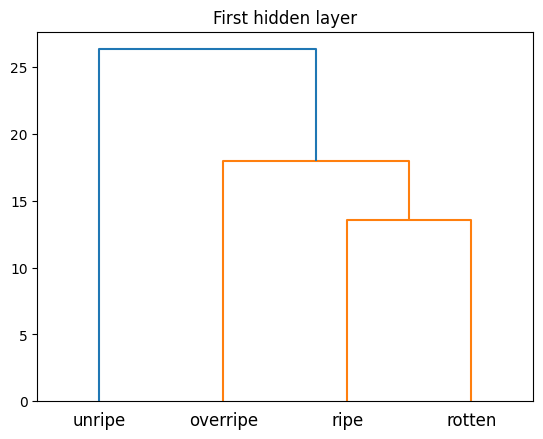

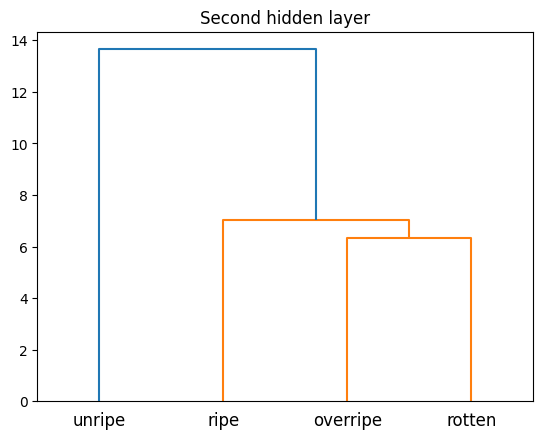

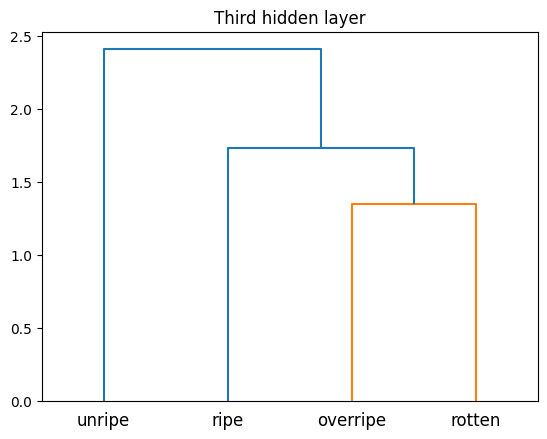

In [71]:

mean_hidd_repr_matrix_1 = get_hidden_reprs_matrix(CNN_hidden1)
mean_hidd_repr_matrix_2 = get_hidden_reprs_matrix(CNN_hidden2) 
mean_hidd_repr_matrix_3 = get_hidden_reprs_matrix(CNN_hidden3)

def plot_dendrogram(mean_repr_matrix, title=""):
  fig, ax = plt.subplots()
  linkage = cluster.hierarchy.linkage(mean_repr_matrix, method="complete")  # we run the clustering algorithm here
  dendrogram = cluster.hierarchy.dendrogram(linkage, labels = train_dataset.classes)
  ax.set_title(title)

plot_dendrogram(mean_hidd_repr_matrix_1, "First hidden layer")
plot_dendrogram(mean_hidd_repr_matrix_2, "Second hidden layer")
plot_dendrogram(mean_hidd_repr_matrix_3, "Third hidden layer")



In [67]:

def mean_interclass_distance(mean_repr_matrix):
    dists = pdist(mean_repr_matrix, metric="euclidean")
    return dists.mean()

print("Layer 1 distance:", mean_interclass_distance(mean_hidd_repr_matrix_1))
print("Layer 2 distance:", mean_interclass_distance(mean_hidd_repr_matrix_2))
print("Layer 3 distance:", mean_interclass_distance(mean_hidd_repr_matrix_3))
# If disentanglement increases → distances should increase with depth.

Layer 1 distance: 20.664057679335553
Layer 2 distance: 9.979364370389847
Layer 3 distance: 1.9060552333107088


For this specific project, there aren't many classes, and all of them are relatively similar.

Still, the distance results are consistent with the earlier linear read-out results.  
Since early layers preserve rich, high-variance information, deeper layers progressively discard variability that is not strictly required.  

Looking at the dendrograms we can see that even though the first layer has greater centroid distance, meaning more disentanglement among the classes, it considers to be closer ripe and rotten bananas, instead of overripe and rotten like the 2nd and 3rd layer. So even though the centroids are further, the clustering iteslf might be more wrong.


### Receptive fields

I will now visualize the receptive fields learned by the first convolutional layer by inspecting its convolutional filters.  
Each filter corresponds to a small spatial template of 3×3 pixels that is applied across the input image to detect specific local patterns.  
These receptive fields reflect the network’s initial stage of processing, where raw pixel information is transformed into basic feature responses that form the foundation for higher-level representations in deeper layers.

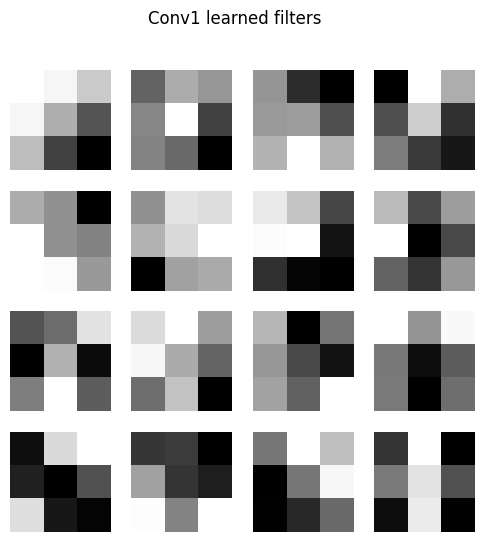

In [ ]:
# receptive fields visualization
def plot_conv1_filters(model, n_filters=16):
    weights = model.conv1[0].weight.data.cpu()
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))

    for i, ax in enumerate(axes.flat):
        if i >= n_filters:
            break
        filt = weights[i].mean(dim=0)  # average over RGB channels
        ax.imshow(filt, cmap="gray")
        ax.axis("off")

    plt.suptitle("Conv1 learned filters")

plot_conv1_filters(CNN["model"])

# 3x3 because kernel_size = 3
# Grayscale visualization (averaged over RGB channels):
# White values = positive weights
# Dark values = negative weights





By taking a look at the receptive fields there isn't much we can understand, but there are some clearer patterns to be found.  
In fact, as expected for early CNN layers, the learned filters resemble edge detectors and simple texture primitives, capturing low-level visual features such as oriented edges, corners, and intensity contrasts.  

This can be seen for example in the first 3x3 that focuses on the top left features, or the one in the bottom right that shows a stright line from top to bottom in the center 

### Max activating inputs

To further interpret the learned representations, I visualize the input images that maximally activate individual feature dimensions in a given hidden layer, here I will use the last one.  
For this layer, I collect the activation values for all samples in the dataset and identify, for each feature dimension, the inputs that produce the highest activation. By displaying these maximally activating inputs, it is possible to gain insight into the types of visual patterns or digit prototypes that specific features respond to. Since it's the last layer, these features are expected to become more selective, responding consistently to particular shapes or structural motifs rather than to simple local patterns.

In [ ]:
def visualize_max_activating_inputs(model, dataloader, feature_idx = 0, layer_key="f3", top_k=5):
    model.eval()
    activations = []
    images = []

    # pass all images through the CNN and extract the activations from the 3rd hidden layer
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            _, feats = model(x)
            act = feats[layer_key] 

            activations.append(act.cpu())
            images.append(x.cpu())

    activations = torch.cat(activations)
    images = torch.cat(images)
    
    # pick one feature dimension
    top_idx = torch.topk(activations[:, feature_idx], top_k).indices

    # find the top_k images that maximize that feature’s activation
    fig, axes = plt.subplots(1, top_k, figsize=(12, 3))
    for i, idx in enumerate(top_idx):
        img_denorm = images[idx] * norm_std[:, None, None] + norm_mean[:, None, None]

        axes[i].imshow(img_denorm.permute(1, 2, 0))
        axes[i].axis("off")
    


    plt.suptitle(f"Top activating inputs for feature {feature_idx}")

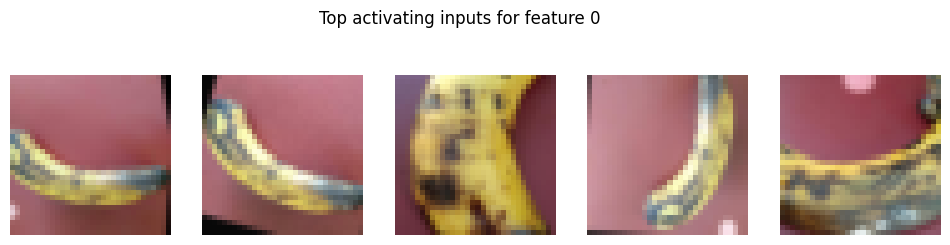

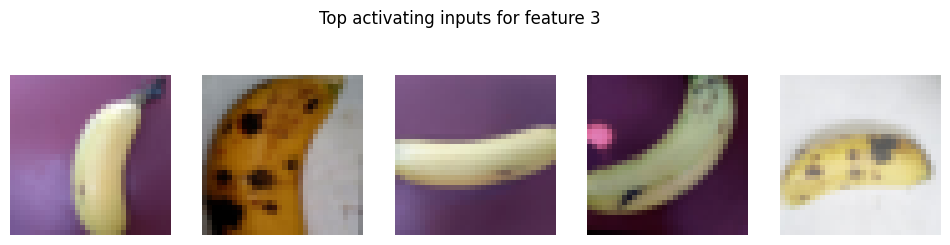

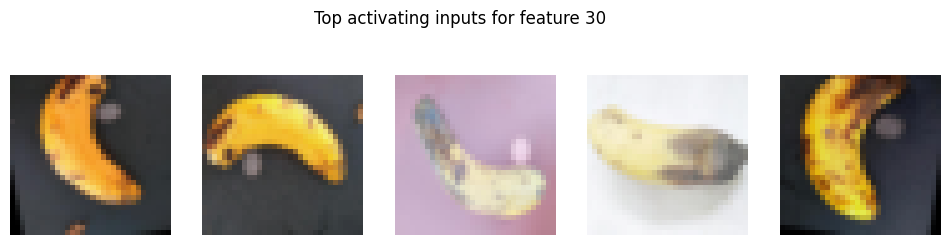

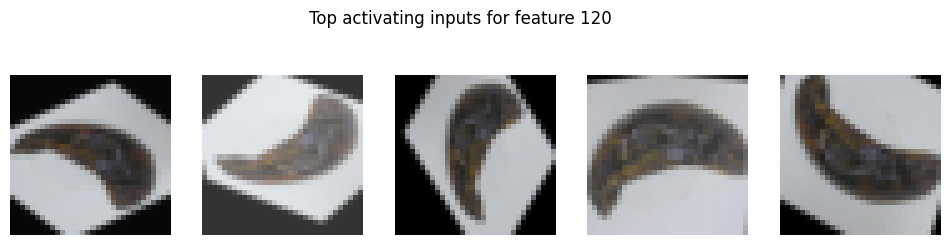

In [79]:


# first 4 activations
visualize_max_activating_inputs(CNN["model"], train_loader, class_label_idx=0) # may give different types of images but mostly 1 kind
visualize_max_activating_inputs(CNN["model"], train_loader, class_label_idx=3)
visualize_max_activating_inputs(CNN["model"], train_loader, class_label_idx=30)
visualize_max_activating_inputs(CNN["model"], train_loader, class_label_idx=120) # 128 total




As expected, we see similar images in each feature, where each has some kind of repeated structural patterns (e.g., spots, color).  
This supports the view that class information is encoded in a distributed and feature-specific manner, rather than through large separation between class centroids.

## Confusion matrix and psychometric curves

### Confusion matrix

Now I'll quickly check the confusion matrix, even though it won't be as helpful as it could since the accuracy of both models is very high.

In [87]:

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    # raw confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # convert to percentages (row-wise)
    cm_sum = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(
        cm, cm_sum, 
        where=cm_sum != 0
    ) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_percent, interpolation='nearest')

    ax.set_title('Confusion Matrix (%) - ' + model_name)
    fig.colorbar(im, ax=ax, format='%.1f%%')

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=90, fontsize=6)
    ax.set_yticklabels(class_names, fontsize=6)

    # annotate each cell with percentage
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            ax.text(
                j, i,
                f"{cm_percent[i, j]:.1f}%",
                ha="center", va="center",
                color="black" if cm_percent[i, j] < 50 else "white",
                fontsize=10
            )

    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")

    plt.tight_layout()



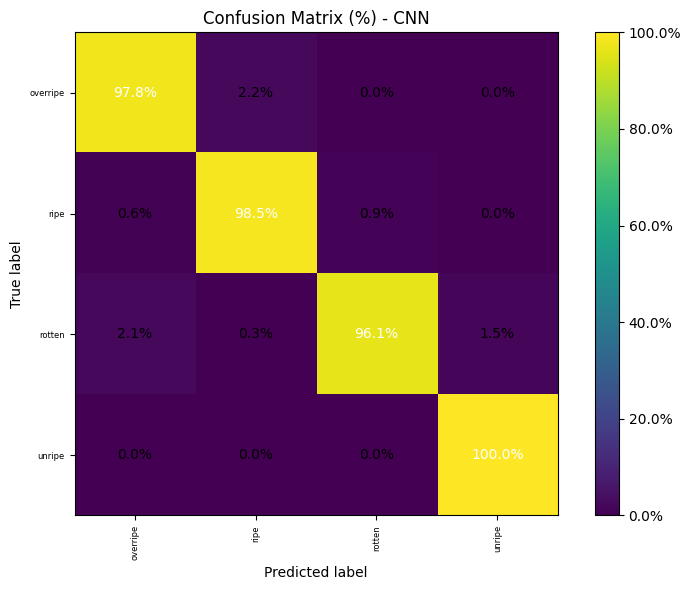

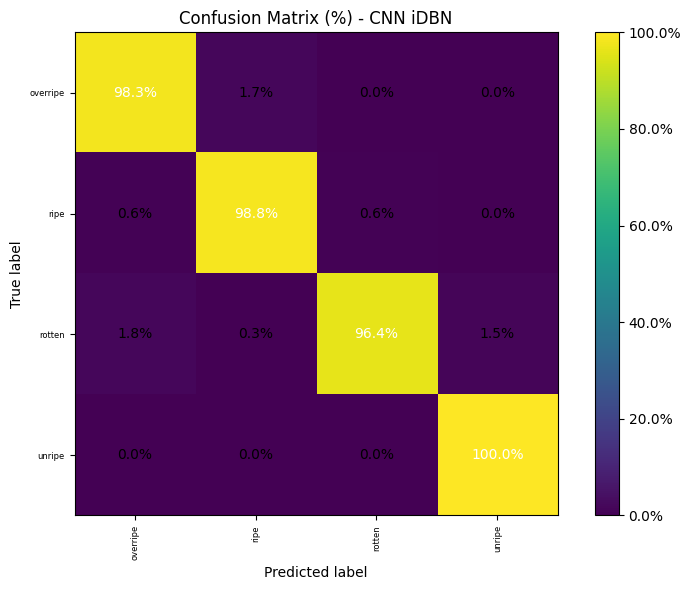

In [88]:
# confusion matrix
plot_confusion_matrix(
    CNN["y_true"], CNN["y_pred"], class_names= train_dataset.classes, model_name="CNN"
) # yellow = more correctly predicted

plot_confusion_matrix(
    CNN_iDBN["y_true"], CNN_iDBN["y_pred"], class_names=train_dataset.classes,  model_name="CNN iDBN"
) # yellow = more correctly predicted

As expected the errors can be just barely seen from the colors alone, still we can get some informations from these plots.
About the single CNN infact, apart from some mistakes that have a class mislabeled by less than 1%, we can see that its greatest mispredictions are about predicting overripe bananas as ripe and rotten bananas as overripe or unripe, which gets a prediction error from 1.5% to 2.2% per case.

We can see though where the improvement of the iDBN comes from, in fact, 2 of the 3 most mislabeled instances have gotten a better prediction, while also the ripe bananas were predicted a bit better.

Also, in both models the best distinguished stage of ripeness is the unripe class, as it could be forseen from the clustering section, since the unripe class was the first clear cut the clustering algorithm made.

### Psychometric curves

Now to see how well the CNN performs with adversarial images injected with noise I will see the psychometric curves.

The simple CNN doesn't have dropout, groupnorm, label smoothing or tuning

In [89]:
# CNN
class simple_ConvolutionalNN(nn.Module):
    """CNN with adaptive pooling so it accepts arbitrary input resolution."""

    def __init__(self, num_classes=n_classes, base_channels=32):
        super().__init__()

        # First convolutional block: low-level feature extraction
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),                                      # groupnorm
            nn.MaxPool2d(2),         # H/2, W/2
        )
        
        # Second block: mid-level features
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),         # H/4, W/4
        )

        # Third block: high-level features + global pooling
        self.conv3 = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*4, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)), # Makes the model independent of input size
        )

        self.embedding_dim = base_channels * 4

        self.classifier = nn.Sequential(
            nn.Linear(self.embedding_dim, num_classes)      # no dropout
        )

    def forward(self, x):
        f1 = self.conv1(x)         # early features
        f2 = self.conv2(f1)        # mid features
        f3 = self.conv3(f2)        # deep features → pooled to (1,1)

        # Flatten everything to (batch, embedding_dim)
        emb = torch.flatten(f3, 1)
        logits = self.classifier(emb) # Class scores
        return logits, {"f1": f1, "f2": f2, "f3": emb}

In [ ]:
simple_CNN_model = ConvolutionalNN().to(device)

simple_CNN_criterion = nn.CrossEntropyLoss().to(device) # no label smoothing

simple_CNN_optimizer = optim.Adam(simple_CNN_model.parameters())
simple_CNN = train(simple_CNN_model, train_loader, val_loader, criterion=simple_CNN_criterion, optimizer=simple_CNN_optimizer, epochs=30)



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7150764..2.7367687].


torch.Size([64, 3, 32, 32])


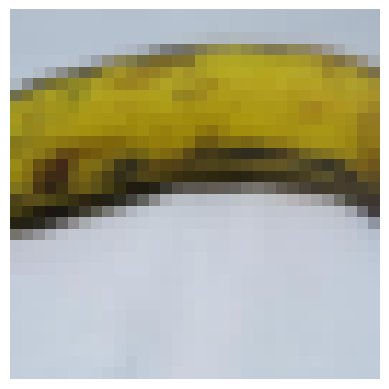

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20489219..1.021773].


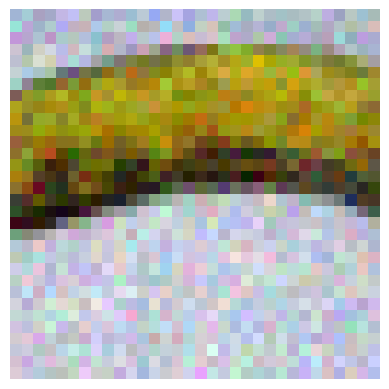

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..2.0648367].


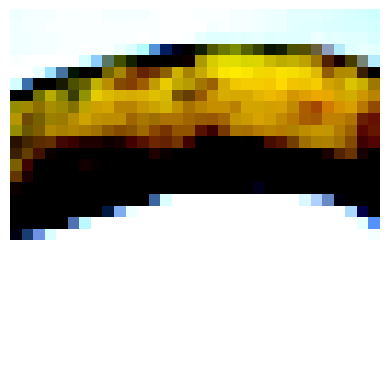

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7150764..2.7367687].


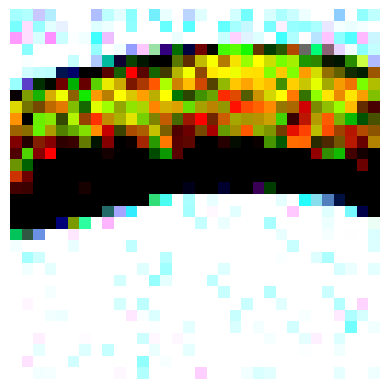

In [92]:
# reminder of the function that use defined earlier:
# def inject_noise(data, noise_level): # given data and noise level create noisy data
#     gaussian_noise = torch.randn(
#         data.shape, # size of the data
#         device = device) * noise_level # might be a problem if like I subtract from total black -> goes negative, not if normalized ?
#     return data + gaussian_noise

x_val, y_val = next(iter(val_loader))


noise_level = 0.3
x_val_with_noise = inject_noise(x_val, noise_level)
print(x_val_with_noise.shape)
img = x_val_with_noise[0].permute(1, 2, 0).cpu()
plt.imshow(img)
plt.axis("off")

plot_image(x_val[0], denorm=True)
plot_image(x_val_with_noise[0], denorm=True)

plot_image(x_val[0])
plot_image(x_val_with_noise[0])



Since I need the hidden representations from the CNN with iDBN too, I'm going to get them right now, using a set of functions that are the same as the ones used for the CNN, but adapted to the iDBN.

In [164]:
def get_representations_CNN_iDBN(model, dataloader, get_labels = False, noise = 0): # noise option added for later
    reps1, reps2, reps3, labels = [], [], [], []

    with torch.no_grad():
        for x, y in dataloader:
            if noise > 0:
                x = inject_noise(x, noise)
            
            x = x.to(device)
            _, feats = model(x)
            h1 = feats["cnn_f3"]
            h2 = feats["idbn_z"]

            # flatten feature maps
            reps1.append(h1.flatten(1))
            reps2.append(h2.flatten(1))

            labels.append(y)
    
    if get_labels:
        return (
            torch.cat(reps1),
            torch.cat(reps2),
            torch.cat(labels)
        )
    else:
        return (
            torch.cat(reps1),
            torch.cat(reps2)
        )

In [158]:
CNN_iDBN_hidden1, CNN_iDBN_hidden2, CNN_iDBN_targets = get_representations_CNN_iDBN(CNN_iDBN["model"], val_loader, get_labels = True, noise = noise_level) # uses the function created at the beginning

CNN_iDBN_linear1 = LinearModel(CNN_iDBN_hidden1.shape[1]).to(device)
CNN_iDBN_linear2 = LinearModel(CNN_iDBN_hidden2.shape[1]).to(device)
train_linear(CNN_iDBN_linear1, CNN_iDBN_hidden1, CNN_iDBN_targets)
train_linear(CNN_iDBN_linear2, CNN_iDBN_hidden2, CNN_iDBN_targets)

Epoch 0, loss=1.4089
Epoch 100, loss=0.1149
Epoch 200, loss=0.1027
Epoch 300, loss=0.0965
Epoch 400, loss=0.0924
Epoch 500, loss=0.0891
Epoch 600, loss=0.0864
Epoch 700, loss=0.0840
Epoch 800, loss=0.0819
Epoch 900, loss=0.0800
Epoch 0, loss=1.3857
Epoch 100, loss=0.3020
Epoch 200, loss=0.2209
Epoch 300, loss=0.1878
Epoch 400, loss=0.1691
Epoch 500, loss=0.1570
Epoch 600, loss=0.1486
Epoch 700, loss=0.1424
Epoch 800, loss=0.1376
Epoch 900, loss=0.1337


In [167]:
# computes accuracy at a certain noise level (psychometric curve)
def get_accuracy_values_at_noise_level(model, noise_level):

  hidden1_noisy, hidden2_noisy, hidden3_noisy = get_representations(model["model"], val_loader, get_labels = False, noise = noise_level) # uses the function created at the beginning
  
  predictions_first_hidden_noisy = CNN_linear1(hidden1_noisy)  # here we use the previously-trained read-out classifiers
  predictions_second_hidden_noisy = CNN_linear2(hidden2_noisy)
  predictions_third_hidden_noisy = CNN_linear3(hidden3_noisy)

  # measure the accuracy
  accuracy_first_hidden = get_accuracy(predictions_first_hidden_noisy, model["y_true"])
  accuracy_second_hidden = get_accuracy(predictions_second_hidden_noisy, model["y_true"])
  accuracy_third_hidden = get_accuracy(predictions_third_hidden_noisy, model["y_true"])


  return accuracy_first_hidden, accuracy_second_hidden, accuracy_third_hidden

def get_accuracy_values_at_noise_level_CNN_iDBN(model, noise_level): 

  hidden1_noisy, hidden2_noisy = get_representations_CNN_iDBN(model["model"], val_loader, get_labels = False, noise = noise_level) # uses the function created at the beginning
  
  predictions_first_hidden_noisy = CNN_iDBN_linear1(hidden1_noisy)  # here we use the previously-trained read-out classifiers
  predictions_second_hidden_noisy = CNN_iDBN_linear2(hidden2_noisy)

  # measure the accuracy
  accuracy_first_hidden = get_accuracy(predictions_first_hidden_noisy, model["y_true"])
  accuracy_second_hidden = get_accuracy(predictions_second_hidden_noisy, model["y_true"])


  return accuracy_first_hidden, accuracy_second_hidden


In [ ]:


CNN_acc1, CNN_acc2, CNN_acc3 = get_accuracy_values_at_noise_level(CNN, noise_level=0.3)
print("Accuracy of 1st hidden layer read-out: %.3f" % CNN_acc1)
print("Accuracy of 2nd hidden layer read-out: %.3f" % CNN_acc2)
print("Accuracy of 3rd hidden layer read-out: %.3f" % CNN_acc3)


CNN_iDBN_acc1, CNN_iDBN_acc2 = get_accuracy_values_at_noise_level_CNN_iDBN(CNN_iDBN, noise_level=0.3)
print("Accuracy of 1st hidden layer read-out: %.3f" % CNN_iDBN_acc1)
print("Accuracy of 2nd hidden layer read-out: %.3f" % CNN_iDBN_acc2)

# We can already see how the iDBN makes the model more resistant to noise


Accuracy of 1st hidden layer read-out: 0.837
Accuracy of 2nd hidden layer read-out: 0.927
Accuracy of 3rd hidden layer read-out: 0.937
Accuracy of 1st hidden layer read-out: 0.972
Accuracy of 2nd hidden layer read-out: 0.964


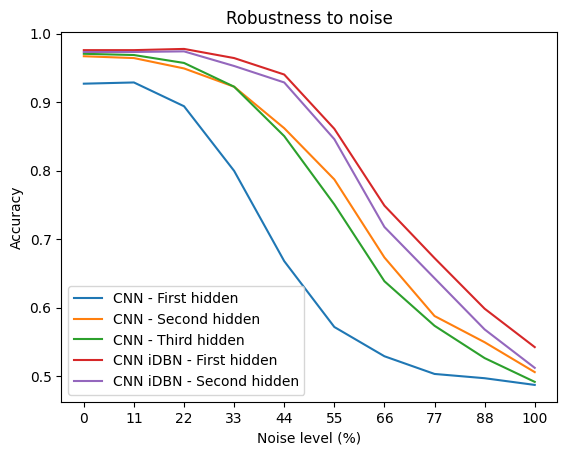

In [ ]:
def plot_noise_robustness_curves(noise_levels):
  CNN_accuracys_hidden1 = []
  CNN_accuracys_hidden2 = []
  CNN_accuracys_hidden3 = []

  CNN_iDBN_accuracys_hidden1 = []
  CNN_iDBN_accuracys_hidden2 = []

  for noise_level in noise_levels:
    CNN_acc1, CNN_acc2, CNN_acc3 = get_accuracy_values_at_noise_level(CNN, noise_level)
    CNN_accuracys_hidden1.append(CNN_acc1)
    CNN_accuracys_hidden2.append(CNN_acc2)
    CNN_accuracys_hidden3.append(CNN_acc3)

    CNN_iDBN_acc1, CNN_iDBN_acc2 = get_accuracy_values_at_noise_level_CNN_iDBN(CNN_iDBN, noise_level)
    CNN_iDBN_accuracys_hidden1.append(CNN_iDBN_acc1)
    CNN_iDBN_accuracys_hidden2.append(CNN_iDBN_acc2)



  fig, ax = plt.subplots()
  ax.plot(range(len(noise_levels)), CNN_accuracys_hidden1)
  ax.plot(range(len(noise_levels)), CNN_accuracys_hidden2)
  ax.plot(range(len(noise_levels)), CNN_accuracys_hidden3)

  ax.plot(range(len(noise_levels)), CNN_iDBN_accuracys_hidden1)
  ax.plot(range(len(noise_levels)), CNN_iDBN_accuracys_hidden2)

  ax.set_title("Robustness to noise")
  ax.set_xlabel("Noise level (%)")
  ax.set_ylabel("Accuracy")
  plt.xticks(range(len(noise_levels)), [int(l*100) for l in noise_levels])
  plt.legend(["CNN - First hidden", "CNN - Second hidden", "CNN - Third hidden", "CNN iDBN - First hidden", "CNN iDBN - Second hidden"])

noise_levels = np.linspace(0,1,10) # creates noise levels
plot_noise_robustness_curves(noise_levels)

# with a bit of noise it drops a lot, 1st hidden layer is very bad, 2nd is good, even better than 3rd
# feed forward is probably overfitting, so that a bit of noise is very impactful
# it's also very sensible to adversarial attacks since it is based only on the initial data



Since even in the CNN I already added many things for noise resistance, the model already looks very solid up to 22% of noise, but then the accuracy starts to decrease rapidly.

We can see though how the iDBN helps not only with accuracy, but also with resistance to noise, shown by how the iDBN lines drop slower compared to the alone CNN. 
Also, there isn't much difference between the 2nd and 3rd layer of the CNN, and also between the 2 layers of the iDBN.

Other possible helps to increase the resistance to noise could come from using noisy images in the training, but I didn't want to show that since an attack could be in many different forms, not simply by gaussian or even more complex noise. That's why I preferred to show how the model could become more robut by changing the model itself instead of the training data.

## Adversarial Attack

For simplicity and to make results more interpretable, I will only do it on the CNN, instead of the CNN + iDBN, like for other parts of the project.

This code implements an adversarial training using the Fast Gradient Sign Method (FGSM).  
FGSM generates adversarial banana images by computing the gradient of the classification loss with respect to the input image and adding a small, controlled perturbation (scaled by ε) in the direction that maximally increases the loss.  
During training and evaluation, the model is exposed to these perturbed images so it learns to be more robust to small, visually imperceptible changes that could otherwise cause misclassification. Additionally, a defensive variant of the CNN optionally applies feature denoising (channel-wise normalization) inside convolutional layers to reduce the impact of adversarial noise, allowing me to compare standard adversarial training versus adversarial training with internal denoising.

Adversarial attack functions

In [35]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image


In [ ]:
def fgsm_attack_cnn(model, image, label, epsilon, device = device):
    image = image.clone().detach().to(device)
    image.requires_grad = True
    label = label.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # Forward pass
    logits = model(image)
    
    loss = criterion(logits, label)
    
    model.zero_grad()
    loss.backward()

    data_grad = image.grad.data
    perturbed_image = fgsm_attack(image, epsilon, data_grad)

    return perturbed_image.detach()


To avoid mistakes for the previous chapters of the project, I'm going to create a train and evaluation function specific for this part, even though they are very similar to the ones used for the normal inference.

In [122]:
def train_epoch_adv(model, loader, optimizer, adversary, epsilon, denoise, device):
    model.train()
    running_loss = 0.0

    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)


    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)

        # Generate adversarial examples
        if adversary:
            images = fgsm_attack_cnn(model, images, labels, epsilon, device)

        optimizer.zero_grad()
        logits = model(images, denoise = denoise)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
def evaluate_under_attack(model, loader, epsilon, denoise=False, device=device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images, labels = images.to(device), labels.to(device)

        if epsilon > 0:
            perturbed_images = fgsm_attack_cnn(
                model, images, labels, epsilon, device
            )
        else:
            perturbed_images = images

        with torch.no_grad():
                
            logits = model(perturbed_images, denoise=denoise)

            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc



For another layer of defense that will be seen later, we implement here a denoising mechanism.  

The denoise_features function computes the mean and standard deviation of each feature map per channel and per image across the height and width dimensions, then standardizes the features to have zero mean and unit variance.

In [34]:
def denoise_features(f):
    mean = f.mean(dim=(2,3), keepdim=True)
    std = f.std(dim=(2,3), keepdim=True) + 1e-6
    return (f - mean) / std

This normalization is then applied after the first and second convolutional layers, which helps suppress small, high-frequency perturbations introduced by adversarial attacks like FGSM. Conceptually, this acts as a form of feature-level denoising, making the learned banana ripeness representations more stable and thus reducing the model’s sensitivity to adversarial input changes without changing the input image itself.

In [ ]:
class DefensiveCNN(ConvolutionalNN):
    def forward(self, x, denoise=False):
        f1 = self.conv1(x)
        if denoise:
            f1 = denoise_features(f1)

        f2 = self.conv2(f1)
        if denoise:
            f2 = denoise_features(f2)

        f3 = self.conv3(f2)
        emb = torch.flatten(f3, 1)
        logits = self.classifier(emb)
        return logits

In [ ]:
def train_adv(model, train_loader, test_loader, optimizer, adversary_train, epsilon=0.03, epochs=10, denoise_train = False, denoise_test = False, device=device, verbose=True):

    train_losses, train_accs, test_losses, test_accs = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch_adv(
            model, train_loader, optimizer, epsilon, adversary_train, denoise = denoise_train, device = device
        )

        test_loss, test_acc = evaluate_under_attack(
            model, test_loader, epsilon, denoise = denoise_test, device = device
        )

        if verbose:
            print(f"Epoch {epoch+1:02d} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Train Acc: {train_acc:.3f} | "
                  f"Test Loss: {test_loss:.4f} | "
                  f"Test Acc: {test_acc:.3f}")

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

    return {
        "model": model,
        "tr_losses": train_losses,
        "tr_accs": train_accs,
        "ts_losses": test_losses,
        "ts_accs": test_accs
    }

In [ ]:
CNN_adv_model = DefensiveCNN().to(device)
CNN_adv_optimizer = optim.Adam(CNN_adv_model.parameters(), lr=0.001, weight_decay=0)

Let's take a look at what the adversarial attack looks like:

torch.Size([3, 32, 32])
Label: 0
Original image


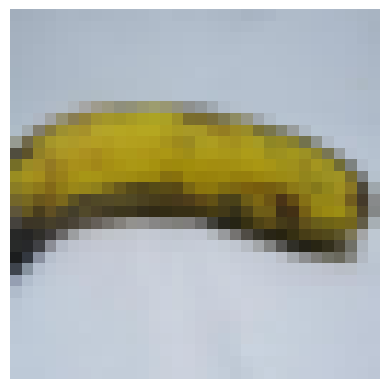

FGSM perturbed image (ε = 0.1)


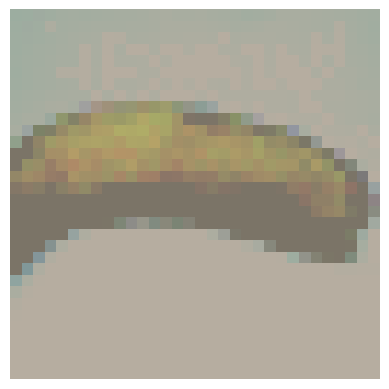

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.0822659].


Original image


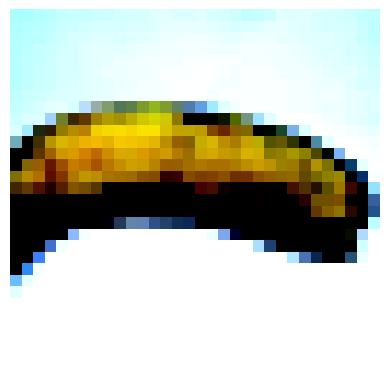

FGSM perturbed image (ε = 0.1)


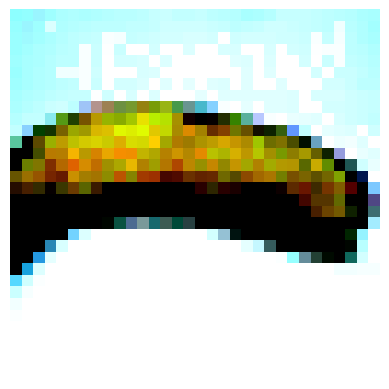

In [ ]:
# Get a single image from the dataset
img, label = train_loader.dataset[11]
print(img.shape)   # [3, 32, 32]

# Add batch dimension and move to device
img_batch = img.unsqueeze(0).to(device)
label_batch = torch.tensor([label]).to(device)

# Generate adversarial (FGSM) image
epsilon = 0.1
perturbed_img = fgsm_attack_cnn(
    CNN_adv_model, img_batch, label_batch, epsilon, device
)

# Remove batch dimension and move to CPU
perturbed_img = perturbed_img.squeeze(0).cpu()

# Plot original image
print("Original image")
plot_image(img, denorm=True)

# Plot perturbed image
print(f"FGSM perturbed image (ε = {epsilon})")
plot_image(perturbed_img, denorm=True)

# Plot original image
print("Original image")
plot_image(img)

# Plot perturbed image
print(f"FGSM perturbed image (ε = {epsilon})")
plot_image(perturbed_img)

We can already see how the normalization alone helps with the classification, while for the original image is much less clear to define the color of the banana because of the attack.

We now see the actual performances of the model under different kinds of situations, by using images attacked with an epsilon set to 0.03, without other epsilon values to avoid repetitive and long results.

First to use as baseline, we see how the model handles the adversarial images by training it with only with normal images.

In [ ]:
CNN_adv_baseline = train_adv(CNN_adv_model, train_loader, val_loader, 
                             optimizer=CNN_adv_optimizer, epochs=10, adversary_train = False, denoise_train = False, denoise_test = False)


Epoch 01 | Train Loss: 0.8696 | Train Acc: 0.659 | Test Loss: 0.7335 | Test Acc: 0.757


Epoch 02 | Train Loss: 0.6710 | Train Acc: 0.773 | Test Loss: 0.7960 | Test Acc: 0.661


Epoch 03 | Train Loss: 0.6277 | Train Acc: 0.799 | Test Loss: 0.6757 | Test Acc: 0.779


Epoch 04 | Train Loss: 0.5792 | Train Acc: 0.828 | Test Loss: 0.5393 | Test Acc: 0.860


Epoch 05 | Train Loss: 0.5347 | Train Acc: 0.855 | Test Loss: 0.5360 | Test Acc: 0.856


Epoch 06 | Train Loss: 0.5171 | Train Acc: 0.862 | Test Loss: 0.5199 | Test Acc: 0.852


Epoch 07 | Train Loss: 0.4992 | Train Acc: 0.876 | Test Loss: 0.5051 | Test Acc: 0.869


Epoch 08 | Train Loss: 0.4768 | Train Acc: 0.881 | Test Loss: 0.5038 | Test Acc: 0.872


Epoch 09 | Train Loss: 0.4788 | Train Acc: 0.882 | Test Loss: 0.4699 | Test Acc: 0.890


Epoch 10 | Train Loss: 0.4713 | Train Acc: 0.885 | Test Loss: 0.4899 | Test Acc: 0.889


The model is already solid to at least this kind of attacks. It manages to get the correct classification almost 90% of the times.


Let's now try to train the model with adversarial images too.

In [ ]:

CNN_adv = train_adv(CNN_adv_model, train_loader, val_loader, 
                optimizer=CNN_adv_optimizer, epochs=10, adversary_train = True, denoise_train = False, denoise_test = False)




Epoch 01 | Train Loss: 0.9685 | Train Acc: 0.585 | Test Loss: 0.7073 | Test Acc: 0.754


Epoch 02 | Train Loss: 0.7451 | Train Acc: 0.724 | Test Loss: 0.6518 | Test Acc: 0.775


Epoch 03 | Train Loss: 0.6896 | Train Acc: 0.762 | Test Loss: 0.6314 | Test Acc: 0.774


Epoch 04 | Train Loss: 0.6339 | Train Acc: 0.795 | Test Loss: 0.5978 | Test Acc: 0.826


Epoch 05 | Train Loss: 0.5989 | Train Acc: 0.816 | Test Loss: 0.5923 | Test Acc: 0.804


Epoch 06 | Train Loss: 0.5749 | Train Acc: 0.832 | Test Loss: 0.5021 | Test Acc: 0.863


Epoch 07 | Train Loss: 0.5366 | Train Acc: 0.853 | Test Loss: 0.5021 | Test Acc: 0.863


Epoch 08 | Train Loss: 0.5276 | Train Acc: 0.856 | Test Loss: 0.4784 | Test Acc: 0.886


Epoch 09 | Train Loss: 0.5253 | Train Acc: 0.857 | Test Loss: 0.4641 | Test Acc: 0.895


Epoch 10 | Train Loss: 0.5050 | Train Acc: 0.870 | Test Loss: 0.4370 | Test Acc: 0.899


For the baseline
The model manages to get a bit more accuracte but not by much, still exposing the model to adversarially perturbed images during training improves its robustness and generalization under attack, even without any additional defensive mechanism. The decreasing loss values suggest stable convergence without severe overfitting.

Finally, let's try with another measure of defense, the denoising.

In [ ]:

CNN_adv_denoise = train_adv(CNN_adv_model, train_loader, val_loader, 
                optimizer=CNN_adv_optimizer, epochs=10, adversary_train = True, denoise_train = True, denoise_test = True)

Epoch 01 | Train Loss: 0.6564 | Train Acc: 0.802 | Test Loss: 0.5155 | Test Acc: 0.870


Epoch 02 | Train Loss: 0.5378 | Train Acc: 0.854 | Test Loss: 0.4845 | Test Acc: 0.878


Epoch 03 | Train Loss: 0.5171 | Train Acc: 0.864 | Test Loss: 0.4456 | Test Acc: 0.904


Epoch 04 | Train Loss: 0.4869 | Train Acc: 0.879 | Test Loss: 0.4292 | Test Acc: 0.907


Epoch 05 | Train Loss: 0.4687 | Train Acc: 0.890 | Test Loss: 0.4356 | Test Acc: 0.903


Epoch 06 | Train Loss: 0.4594 | Train Acc: 0.890 | Test Loss: 0.4174 | Test Acc: 0.907


Epoch 07 | Train Loss: 0.4402 | Train Acc: 0.903 | Test Loss: 0.4309 | Test Acc: 0.891


Epoch 08 | Train Loss: 0.4471 | Train Acc: 0.899 | Test Loss: 0.4080 | Test Acc: 0.908


Epoch 09 | Train Loss: 0.4287 | Train Acc: 0.905 | Test Loss: 0.3781 | Test Acc: 0.936


Epoch 10 | Train Loss: 0.4136 | Train Acc: 0.913 | Test Loss: 0.3810 | Test Acc: 0.935


The model starts with a much higher initial accuracy and converges to a test accuracy of 93.5%, outperforming the non-denoised adversarial model by a significant margin.

Adversarial robustness is not about keeping 97% accuracy.
Since the objecive isn't about getting the same accuracy as the original inference, but about losing less accuracy than an undefended model.
Results show that adversarial training plus the denoising provides the strongest robustness improvement, particularly at moderate perturbation levels, while preserving strong and clean accuracy. 



## Final evaluation on the test set

For good measures we try the tuned CNN iDBN hybrid model with the test set, which was already defined in the datatset file

In [153]:
CNN_iDBN_model_test = CovolutionalNN_iDBN(cnn, idbn, num_classes=n_classes).to(device)

CNN_iDBN_optimizer_test = optim.Adam(CNN_iDBN_model_test.classifier.parameters(), lr=5e-3)
CNN_iDBN_criterion_test = nn.CrossEntropyLoss(label_smoothing=0.05)

CNN_iDBN_test = train(CNN_iDBN_model_test, train_loader, test_loader, criterion=CNN_iDBN_criterion_test, optimizer=CNN_iDBN_optimizer_test, epochs=30, is_CNN = False)


Epoch 01 | Train Loss: 0.3757 | Train Acc: 0.953 | Test Loss: 0.2724 | Test Acc: 0.977


Epoch 02 | Train Loss: 0.2683 | Train Acc: 0.975 | Test Loss: 0.2622 | Test Acc: 0.980


Epoch 03 | Train Loss: 0.2616 | Train Acc: 0.979 | Test Loss: 0.2624 | Test Acc: 0.979


Epoch 04 | Train Loss: 0.2607 | Train Acc: 0.979 | Test Loss: 0.2589 | Test Acc: 0.982


Epoch 05 | Train Loss: 0.2552 | Train Acc: 0.980 | Test Loss: 0.2590 | Test Acc: 0.986


...

Epoch 26 | Train Loss: 0.2497 | Train Acc: 0.983 | Test Loss: 0.2556 | Test Acc: 0.984


Epoch 27 | Train Loss: 0.2518 | Train Acc: 0.982 | Test Loss: 0.2575 | Test Acc: 0.984


Epoch 28 | Train Loss: 0.2500 | Train Acc: 0.983 | Test Loss: 0.2555 | Test Acc: 0.984


Epoch 29 | Train Loss: 0.2501 | Train Acc: 0.984 | Test Loss: 0.2559 | Test Acc: 0.984


Epoch 30 | Train Loss: 0.2480 | Train Acc: 0.984 | Test Loss: 0.2571 | Test Acc: 0.982


We get even better results than in both the training and the validatiom, probably because the train and validation are both very representative of the test set, and also due to the fact that the dataset dimension is notably smaller (Train: 11793, Val: 1123, Test: 562), so there are less chances for difficult images to appear.

In conclusion, this project examined the performance of a convolutional neural network and a hybrid CNN–iDBN architecture for banana ripeness classification. The standalone CNN provided a solid baseline and allowed for detailed analysis of learned representations through linear readouts and clustering, offering insight into how ripeness information is encoded. 

Incorporating the iDBN led to measurable improvements in classification performance and increased robustness to noise and adversarial perturbations, suggesting that the additional unsupervised modeling of CNN embeddings can enhance representation quality. 

Overall, the comparative analysis highlights the strengths and limitations of each approach and underscores the value of combining convolutional feature extraction with probabilistic deep models for improved generalization and stability, and both approaches achieved strong results while remaining computationally efficient, demonstrating that compact models can effectively handle this kind of problems.